<a href="https://colab.research.google.com/github/Sumit05-Y/EDA-DATASCIENCE/blob/main/NEPSE(NLIC).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

nlic=pd.read_csv("NLICONEYEARCSV.csv")
nlic.shape
nlic.ndim
nlic.head()
nlic.tail()
nlic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223 entries, 0 to 222
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Symbol          223 non-null    object 
 1   Date            223 non-null    object 
 2   Open            223 non-null    float64
 3   High            223 non-null    float64
 4   Low             223 non-null    float64
 5   Close           223 non-null    float64
 6   Percent Change  223 non-null    object 
 7   Volume          223 non-null    object 
 8   Turn Over       223 non-null    object 
dtypes: float64(4), object(5)
memory usage: 15.8+ KB


In [7]:
nlic["Date"] = pd.to_datetime(nlic["Date"])
nlic["Volume"] =nlic["Volume"].replace("-",np.nan)
nlic["Volume"] = nlic["Volume"].str.replace(",","",regex=False).astype(float)

In [12]:
nlic["Percent Change"]=nlic["Percent Change"].str.replace("%",'',regex=False).str.strip().astype(float)

In [13]:
nlic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223 entries, 0 to 222
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Symbol          223 non-null    object        
 1   Date            223 non-null    datetime64[ns]
 2   Open            223 non-null    float64       
 3   High            223 non-null    float64       
 4   Low             223 non-null    float64       
 5   Close           223 non-null    float64       
 6   Percent Change  223 non-null    float64       
 7   Volume          125 non-null    float64       
 8   Turn Over       223 non-null    object        
dtypes: datetime64[ns](1), float64(6), object(2)
memory usage: 15.8+ KB


In [14]:
nlic = nlic.drop(columns = ["Symbol","Turn Over"])

In [16]:
nlic=nlic.sort_values("Date").reset_index(drop=True)
nlic.head()


,Date,Open,High,Low,Close,Percent Change,Volume
0,2025-07-08,735.238095,739.428571,724.761905,729.047619,-0.40,NaN
1,2025-07-09,727.619048,737.142857,727.619048,729.228571,0.02,NaN
2,2025-07-10,726.666667,744.761905,726.666667,738.085714,1.21,NaN
3,2025-07-13,752.380952,767.619048,738.095238,740.209524,0.29,NaN
4,2025-07-14,752.380952,752.380952,729.523810,731.352381,-1.20,NaN


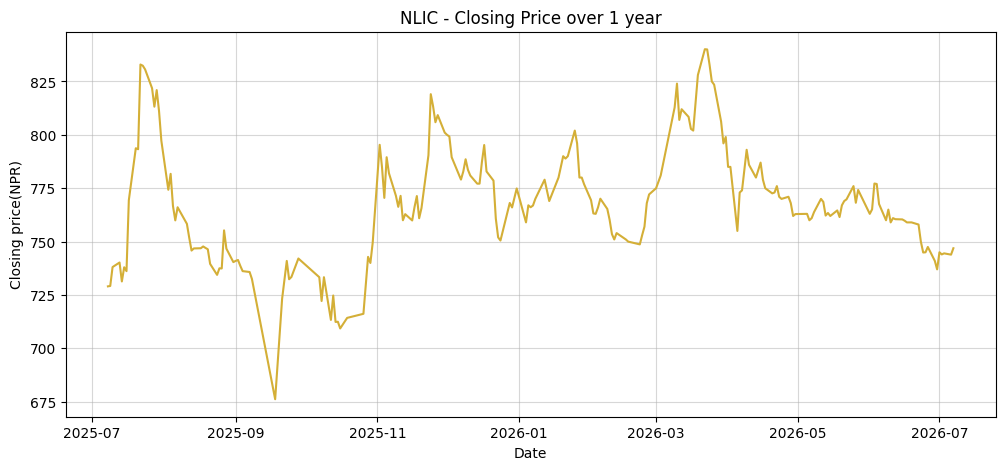

In [18]:
plt.figure(figsize=(12,5))
plt.plot(nlic["Date"],nlic["Close"], color="#D4AF37", linewidth=1.5)
plt.title("NLIC - Closing Price over 1 year")
plt.xlabel("Date")
plt.ylabel("Closing price(NPR)")
plt.grid(True , alpha = 0.5)

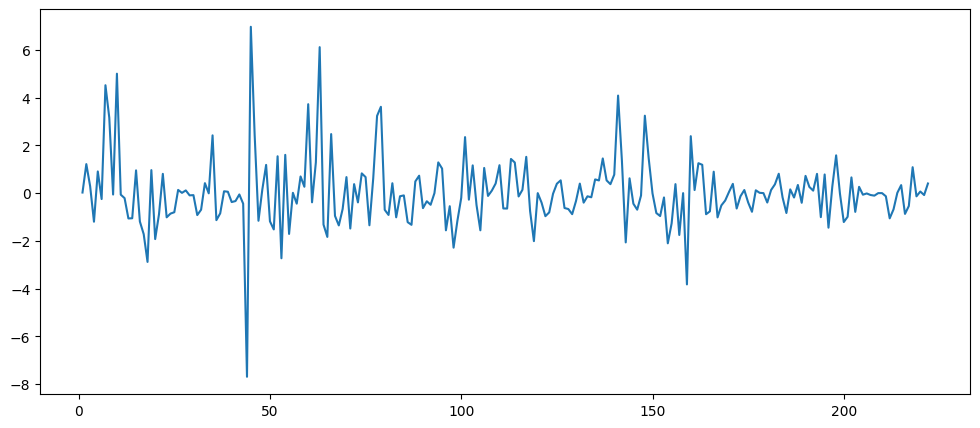

In [20]:
nlic["Daily Return"] = nlic["Close"].pct_change()*100
plt.figure(figsize=(12,5))
plt.plot(nlic["Daily Return"])

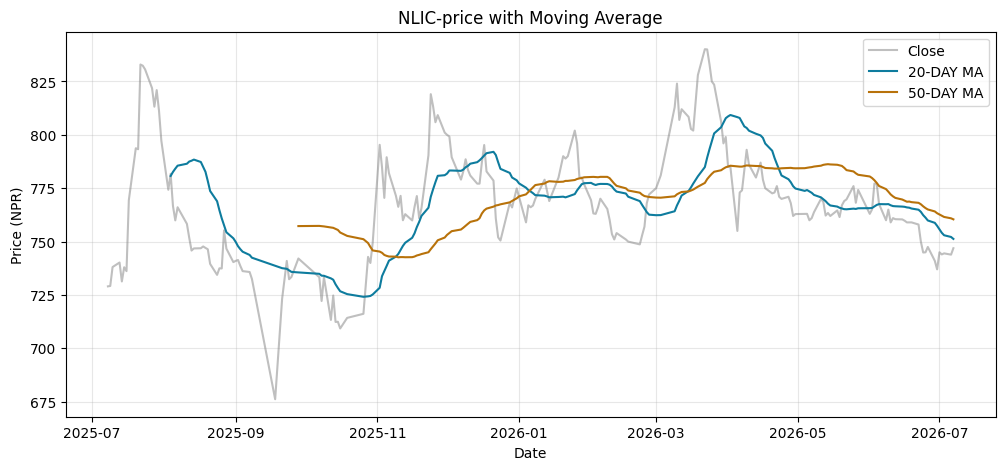

In [21]:
nlic['MA20'] = nlic['Close'].rolling(window=20).mean()
nlic['MA50'] = nlic['Close'].rolling(window=50).mean()

plt.figure(figsize=(12,5))
plt.plot(nlic['Date'], nlic['Close'],label='Close',alpha=0.5, color='gray')
plt.plot(nlic['Date'], nlic['MA20'],label='20-DAY MA',color='#0E7C9E')
plt.plot(nlic['Date'], nlic['MA50'],label='50-DAY MA', color='#B8720A')
plt.title("NLIC-price with Moving Average")
plt.xlabel("Date")
plt.ylabel("Price (NPR)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

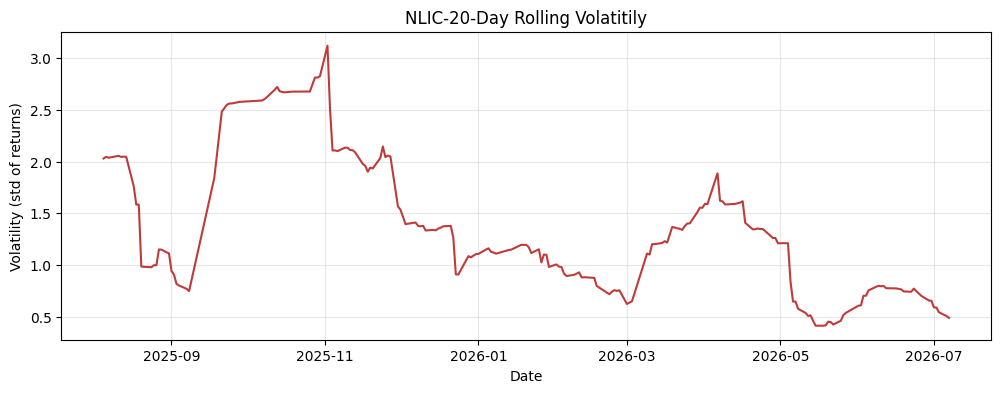

In [22]:
nlic['Volatility'] = nlic["Daily Return"].rolling(window=20).std()

plt.figure(figsize=(12,4))
plt.plot(nlic["Date"],nlic['Volatility'], color ="#C13A3A")
plt.title("NLIC-20-Day Rolling Volatitily")
plt.xlabel("Date")
plt.ylabel("Volatility (std of returns)")
plt.grid(True,alpha=0.3)
plt.show()

In [23]:
nlic.to_csv("NLIC_CLEAN.csv", index=False)
print("Saved NLIC_CLEAN.csv — ready for Day 10")

from google.colab import files
files.download("NLIC_CLEAN.csv")


Saved NLIC_CLEAN.csv — ready for Day 10


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>